# Netflix Data Cleaning and EDA

This notebook cleans the raw Netflix titles dataset, engineers a few useful features, and performs a small exploratory analysis. The output is saved to `data/processed/netflix_clean.csv` so it can power the Streamlit dashboard.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

## Load data

In [2]:
raw_path = Path('../data/raw/netflix_titles.csv')
df = pd.read_csv(raw_path)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Initial audit

In [3]:
print('Shape:', df.shape)
df.info()
df.isna().sum().sort_values(ascending=False).head(12)

Shape: (8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

## Cleaning and feature engineering

In [4]:
clean = df.copy()

# Standardize column names
clean.columns = [c.strip().lower().replace(' ', '_') for c in clean.columns]

# Parse dates
clean['date_added'] = pd.to_datetime(clean['date_added'], errors='coerce')
clean['year_added'] = clean['date_added'].dt.year
clean['month_added'] = clean['date_added'].dt.month_name()

# Clean text fields
for col in ['director', 'cast', 'country', 'rating', 'listed_in']:
    if col in clean.columns:
        clean[col] = clean[col].fillna('Unknown').astype(str).str.strip()

# Split duration into numeric value and unit
if 'duration' in clean.columns:
    duration_split = clean['duration'].astype(str).str.extract(r'(?P<duration_value>\d+)\s*(?P<duration_unit>\w+)')
    clean['duration_value'] = pd.to_numeric(duration_split['duration_value'], errors='coerce')
    clean['duration_unit'] = duration_split['duration_unit'].str.lower()

# Remove exact duplicates
clean = clean.drop_duplicates()

# Create helper features
clean['is_movie'] = clean['type'].eq('Movie')
clean['is_tv_show'] = clean['type'].eq('TV Show')

clean.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_value,duration_unit,is_movie,is_tv_show
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,September,90.0,min,True,False
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,September,2.0,seasons,False,True
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,September,1.0,season,False,True
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,September,1.0,season,False,True
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,September,2.0,seasons,False,True


## Save cleaned data

In [5]:
processed_path = Path('../data/processed/netflix_clean.csv')
processed_path.parent.mkdir(parents=True, exist_ok=True)
clean.to_csv(processed_path, index=False)
processed_path

WindowsPath('../data/processed/netflix_clean.csv')

## Basic exploratory analysis

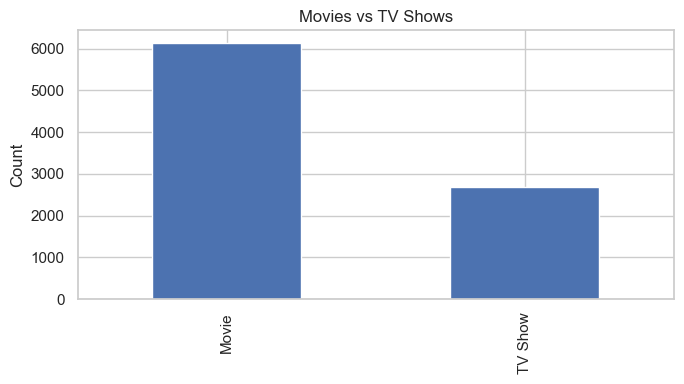

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
clean['type'].value_counts().plot(kind='bar', ax=ax)
ax.set_title('Movies vs TV Shows')
ax.set_xlabel('')
ax.set_ylabel('Count')
plt.tight_layout()

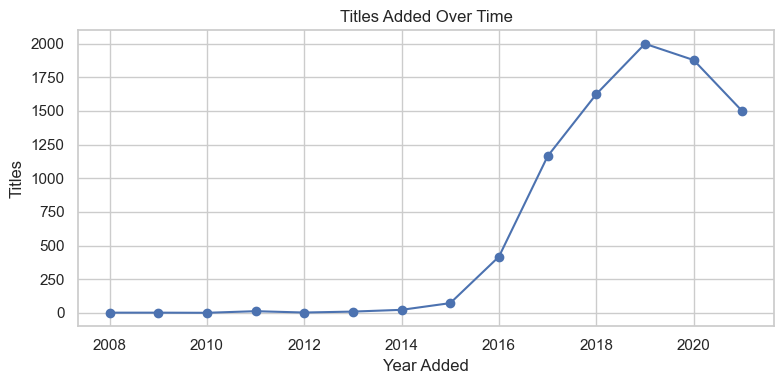

In [7]:
yearly = clean.groupby('year_added', dropna=True).size().reset_index(name='count')
yearly = yearly.sort_values('year_added')
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(yearly['year_added'], yearly['count'], marker='o')
ax.set_title('Titles Added Over Time')
ax.set_xlabel('Year Added')
ax.set_ylabel('Titles')
plt.tight_layout()

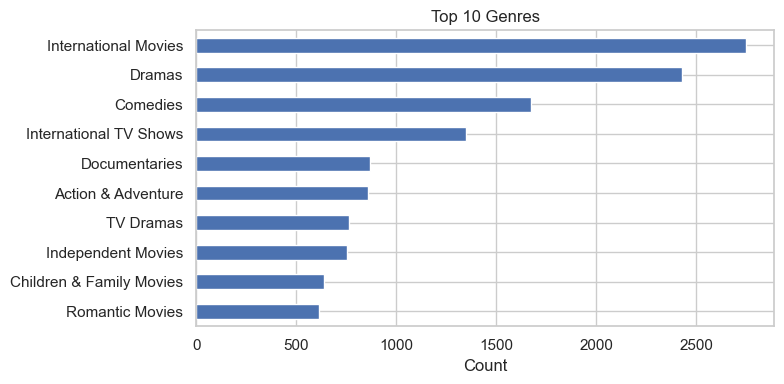

In [8]:
genres = clean['listed_in'].fillna('Unknown').str.split(',').explode().str.strip()
top_genres = genres.value_counts().head(10)
fig, ax = plt.subplots(figsize=(8, 4))
top_genres.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top 10 Genres')
ax.set_xlabel('Count')
ax.set_ylabel('')
plt.tight_layout()

## Summary insights

In [9]:
summary = pd.DataFrame({
    'metric': ['total_titles', 'movies', 'tv_shows', 'countries'],
    'value': [
        len(clean),
        int(clean['type'].eq('Movie').sum()),
        int(clean['type'].eq('TV Show').sum()),
        int(clean['country'].nunique()),
    ],
})
summary

,metric,value
0,total_titles,8807
1,movies,6131
2,tv_shows,2676
3,countries,749


### Interpretation
- The dataset is primarily useful for content mix and trend analysis.
- Cleaning focuses on date parsing, duplicate removal, and splitting compound fields.
- The processed file is designed for the Streamlit dashboard.